In [1]:
#@title SETUP

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os, random
import torch
import torch.nn as nn
import torch.optim as optim


from dataclasses import dataclass
from typing import Dict, Tuple, List

In [3]:
#@title 1. CONFIG & DEVICE

# ==================
# function: set seed
# ==================
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)

# ========================
# dataclass: configuration
# ========================
@dataclass
class GenConfig:
    dim_c: int = 10
    dim_s: int = 10
    mix_hidden: int = 64

    noise_c: float = 1.0
    noise_s: float = 1.0
    noise_t: float = 0.15      # make shortcut channel

    rho: float = 0.9           # strong spurious vector correlation
    gamma: float = 10.0        # make shortcut very salient
    alpha_spur: float = 6.0    # strong shortcut correlation with q



# define device
device = "cuda" if torch.cuda.is_available() else "cpu"
out_dir = "./out"
ensure_dir(out_dir)

In [4]:
#@title 2. DATA GENERATION

# ==================================================
# class: fixed feature mixer g; we can ablate over g
# ==================================================
class FixedMixer(nn.Module):
    """
    Frozen random nonlinear feature mixer for [c;s]. Hidden representation
    """
    def __init__(self, in_dim: int, hidden: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, out_dim),
            nn.Tanh(),
        )
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

# =========================
# class: shortcut generator
# =========================
class ShortcutGenerator:
    """
    Latent:
      q ~ N(0,1)
      c = q + eps_c; here we set f_c = id. We can ablate this as required
      s = rho_sign * rho * q + eps_s; same, f_s = id. We can ablate this as required
      t = rho_sign * alpha_spur * q + eps_t   (scalar shortcut)
    Observed:
      phi = [ mixer([c;s]) ; gamma*t ]
    """
    def __init__(self, cfg: GenConfig, device="cpu"):
        self.cfg = cfg
        self.device = device
        self.mixer = FixedMixer(cfg.dim_c + cfg.dim_s, cfg.mix_hidden, cfg.dim_c + cfg.dim_s).to(device)

    def sample_latents(self, n: int, rho_sign: float) -> Dict[str, torch.Tensor]:
        cfg = self.cfg
        q = torch.randn(n, 1, device=self.device)

        eps_c = cfg.noise_c * torch.randn(n, cfg.dim_c, device=self.device)
        eps_s = cfg.noise_s * torch.randn(n, cfg.dim_s, device=self.device)
        eps_t = cfg.noise_t * torch.randn(n, 1, device=self.device)

        c = q.repeat(1, cfg.dim_c) + eps_c
        s = (rho_sign * cfg.rho) * q.repeat(1, cfg.dim_s) + eps_s
        t = (rho_sign * cfg.alpha_spur) * q + eps_t

        return {"q": q, "c": c, "s": s, "t": t}

    def build_phi(self, c: torch.Tensor, s: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        base = self.mixer(torch.cat([c, s], dim=1))
        return torch.cat([base, self.cfg.gamma * t], dim=1)

    def sample_phi(self, n: int, rho_sign: float) -> Dict[str, torch.Tensor]:
        lat = self.sample_latents(n, rho_sign=rho_sign)
        lat["phi"] = self.build_phi(lat["c"], lat["s"], lat["t"])
        return lat

    def counterfactual_phi(self, lat: Dict[str, torch.Tensor]) -> torch.Tensor:
        # For tie-training, flip ONLY spurious (s,t). Keep causal c fixed.
        return self.build_phi(lat["c"], -lat["s"], -lat["t"])

In [5]:
#@title 3. PAIR SAMPLING

# =============================
# function: sample strict pairs
# =============================
def sample_strict_pairs(gen: ShortcutGenerator,
                        n_pairs: int,
                        beta_teacher: float,
                        rho_sign: float) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Strict pairs: label comes from true utility q via Bradley-Terry.
    """
    a = gen.sample_phi(n_pairs, rho_sign=rho_sign)
    b = gen.sample_phi(n_pairs, rho_sign=rho_sign)
    q1 = a["q"].squeeze(1)
    q2 = b["q"].squeeze(1)
    logits = beta_teacher * (q1 - q2)
    y = torch.bernoulli(torch.sigmoid(logits)).float().unsqueeze(1)
    return a["phi"], b["phi"], y

# =============================================
# function: sample tie pairs with spurious flip
# =============================================
def sample_tie_pairs_spurious_flip(gen: ShortcutGenerator,
                                  n_pairs: int,
                                  rho_sign: float) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    IMPORTANT: Tie pairs with equal utility but conflicting spurious signal as predicted by the theory.

    Construction:
      - Sample latent (q,c,s,t) once.
      - Create two candidates:
          A: (c,  s,  t)
          B: (c, -s, -t)
      - Random label (tie): y ~ Bernoulli(0.5)
    """
    lat = gen.sample_latents(n_pairs, rho_sign=rho_sign)
    phi_a = gen.build_phi(lat["c"], lat["s"], lat["t"])
    phi_b = gen.build_phi(lat["c"], -lat["s"], -lat["t"])
    y = torch.randint(0, 2, (n_pairs, 1), device=gen.device).float()
    return phi_a, phi_b, y

# ========================================================
# function: mixture model: alpha * P + (1 - alpha) * P_tie
# ========================================================
def mix_pairs(strict, ties, alpha: float) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    alpha = fraction strict (so 1-alpha = fraction ties).
    Output has the same total size as the strict input.
    """
    phi1_s, phi2_s, y_s = strict
    phi1_t, phi2_t, y_t = ties
    n = phi1_s.shape[0]
    n_s = int(round(alpha * n))
    n_t = n - n_s

    idx_s = torch.randperm(n, device=phi1_s.device)[:n_s]
    idx_t = torch.randperm(n, device=phi1_t.device)[:n_t]

    phi1 = torch.cat([phi1_s[idx_s], phi1_t[idx_t]], dim=0)
    phi2 = torch.cat([phi2_s[idx_s], phi2_t[idx_t]], dim=0)
    y = torch.cat([y_s[idx_s], y_t[idx_t]], dim=0)

    perm = torch.randperm(n, device=phi1.device)
    return phi1[perm], phi2[perm], y[perm]

In [6]:
#@title 4. MODEL

# =================
# class: Scorer MLP
# =================
class ScorerMLP(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, phi: torch.Tensor) -> torch.Tensor:
        return self.net(phi)

In [7]:
#@title 5. TRAINING

# ====================
# funcion: train model
# ====================
def train_pairwise(model: nn.Module,
                   phi1: torch.Tensor,
                   phi2: torch.Tensor,
                   y: torch.Tensor,
                   beta_model: float = 1.0,
                   lr: float = 2e-3,
                   weight_decay: float = 1e-4,
                   epochs: int = 8,
                   batch_size: int = 1024) -> None:
    model.train()
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()

    n = phi1.shape[0]
    for _ in range(epochs):
        perm = torch.randperm(n, device=phi1.device)
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            r1 = model(phi1[idx]).squeeze(1)
            r2 = model(phi2[idx]).squeeze(1)
            logits = beta_model * (r1 - r2)
            loss = loss_fn(logits, y[idx].squeeze(1))
            opt.zero_grad()
            loss.backward()
            opt.step()

In [8]:
#@title 6. METRICS

# ============
# Spurious Gap
# ============
@torch.no_grad()
def spurious_gap_P(model: nn.Module,
                   gen: ShortcutGenerator,
                   n_pairs: int) -> Tuple[float, float, float]:
    """
    Spurious gap on P:
      gapP = Acc(aligned) - Acc(misaligned)

    Alignment rule:
      aligned iff sign(q1 - q2) == sign(t1 - t2),
    where t is the (latent) shortcut scalar before multiplying by gamma.

    Accuracy is computed against the deterministic ground-truth preference y* = 1[q1 > q2].
    This isolates spurious alignment effects (no annotator noise).
    """
    model.eval()

    a = gen.sample_latents(n_pairs, rho_sign=+1.0)
    b = gen.sample_latents(n_pairs, rho_sign=+1.0)

    phi1 = gen.build_phi(a["c"], a["s"], a["t"])
    phi2 = gen.build_phi(b["c"], b["s"], b["t"])

    q1 = a["q"].squeeze(1)
    q2 = b["q"].squeeze(1)
    t1 = a["t"].squeeze(1)
    t2 = b["t"].squeeze(1)

    # deterministic ground-truth label: which has higher q
    y_star = (q1 > q2).float()

    # model prediction
    r1 = model(phi1).squeeze(1)
    r2 = model(phi2).squeeze(1)
    pred = (r1 > r2).float()

    # aligned if spurious shortcut ranks the same way as q
    aligned = ((q1 - q2).sign() == (t1 - t2).sign())

    valid = ((q1 - q2).abs() > 1e-12) & ((t1 - t2).abs() > 1e-12)
    aligned = aligned & valid
    misaligned = (~aligned) & valid

    acc_aligned = (pred[aligned] == y_star[aligned]).float().mean().item()
    acc_misaligned = (pred[misaligned] == y_star[misaligned]).float().mean().item()
    gapP = acc_aligned - acc_misaligned
    return acc_aligned, acc_misaligned, gapP


# ====================
# Conterfactual Margin
# ====================
@torch.no_grad()
def counterfactual_margin(model: nn.Module, gen: ShortcutGenerator, n: int, rho_sign: float) -> float:
    model.eval()
    lat = gen.sample_phi(n, rho_sign=rho_sign)
    phi_cf = gen.counterfactual_phi(lat)
    r = model(lat["phi"]).squeeze(1)
    r_cf = model(phi_cf).squeeze(1)
    return (r - r_cf).abs().mean().item()

# ====================
# Adversarial Accuracy
# ====================
@torch.no_grad()
def adversarial_accuracy(model: nn.Module, gen: ShortcutGenerator, n_pairs: int, beta_teacher: float) -> float:
    """
    Evaluate on Q_adv: rho_sign = -1 (spurious flips).
    Labels still come from q, but spurious correlation reverses.
    """
    model.eval()
    phi1, phi2, y = sample_strict_pairs(gen, n_pairs, beta_teacher=beta_teacher, rho_sign=-1.0)
    r1 = model(phi1).squeeze(1)
    r2 = model(phi2).squeeze(1)
    pred = (r1 > r2).float()
    return (pred == y.squeeze(1)).float().mean().item()

In [9]:
#@title 7. EXPERIMENTS

# ================
# Run gap vs alpha
# ================
def run_gapP_vs_alpha(out_dir: str,
                      device: str,
                      seeds: List[int],
                      alphas: List[float],
                      n_train_pairs: int = 50000,
                      beta_teacher: float = 1.0,        # was 2.0
                      n_eval_pairs: int = 30000,
                      cfg: GenConfig = GenConfig()):
    """
    Spurious gap on P vs alpha for nonlinear preference model.
    """
    ensure_dir(out_dir)
    in_dim = (cfg.dim_c + cfg.dim_s) + 1

    rows = []
    for alpha in sorted(alphas, reverse=True):
        gaps = []
        for sd in seeds:
            set_seed(3000 + sd)
            gen = ShortcutGenerator(cfg, device=device)

            # Train either strict-only or tie learning mixture
            strict = sample_strict_pairs(gen, n_train_pairs, beta_teacher=beta_teacher, rho_sign=+1.0)
            ties = sample_tie_pairs_spurious_flip(gen, n_train_pairs, rho_sign=+1.0)
            train = mix_pairs(strict, ties, alpha=alpha)

            model = ScorerMLP(in_dim=in_dim, hidden=128).to(device)
            train_pairwise(model, *train)

            _, _, gapP = spurious_gap_P(model, gen, n_pairs=n_eval_pairs)
            gaps.append(gapP)

        gaps = np.array(gaps, float)
        rows.append({
            "alpha_strict": alpha,
            "gapP_mean": float(gaps.mean()),
            "gapP_std": float(gaps.std(ddof=1)) if len(gaps) > 1 else 0.0,
        })

    # --- DATA PREP ---
    df = pd.DataFrame(rows).sort_values("alpha_strict", ascending=False).reset_index(drop=True)
    df.to_csv(os.path.join(out_dir, "gapP_vs_alpha.csv"), index=False)

    # Extract data
    a = df["alpha_strict"].to_numpy()
    m = df["gapP_mean"].to_numpy()
    s = df["gapP_std"].to_numpy()

    # --- PLOTTING ---
    # Create figure with the specific dimensions
    fig, ax = plt.subplots(figsize=(5, 4))

    # Plot Main Line
    ax.plot(a, m, '-o',
        label='Spurious Gap',
        color='#2E7D32',       # Green (matching Tie Learning style)
        linewidth=2.0,
        markersize=7,
        alpha=0.9)

    # Plot Error Band
    ax.fill_between(a, m - s, m + s,
                color='#2E7D32',
                alpha=0.15)

    # --- AXIS & STYLING ---
    ax.invert_xaxis()  # 1.0 (Strict) -> 0.0 (Ties)

    # Labels with LaTeX formatting
    ax.set_xlabel('Fraction of Strict Preferences', fontsize=20)
    ax.set_ylabel('Spurious Gap', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_title('Impact of Tie Learning on Spurious Gap', fontsize=11, pad=10)

    # Grid
    ax.grid(True, alpha=0.3, linewidth=0.25)

    # Save and Show (Order matters!)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "spurious_gap_nonlinear_main.pdf"), dpi=300, bbox_inches='tight')
    plt.show()

    return df


# ======================
# Run cg_margin vs alpha
# ======================
def run_cf_margin_vs_alpha(out_dir: str,
                           device: str,
                           seeds: List[int],
                           alphas: List[float],
                           n_train_pairs: int = 50000,
                           beta_teacher: float = 2.0,
                           n_eval_cf: int = 20000,
                           cfg: GenConfig = GenConfig()):
    """
    More ties (smaller α) => LESS shortcut reliance => LOWER CF margin.
    We have an increasing curve, plot (-CF margin).
    """
    ensure_dir(out_dir)
    in_dim = (cfg.dim_c + cfg.dim_s) + 1

    rows = []
    for alpha in sorted(alphas, reverse=True):
        vals = []
        for sd in seeds:
            set_seed(1000 + sd)
            gen = ShortcutGenerator(cfg, device=device)

            strict = sample_strict_pairs(gen, n_train_pairs, beta_teacher=beta_teacher, rho_sign=+1.0)
            ties = sample_tie_pairs_spurious_flip(gen, n_train_pairs, rho_sign=+1.0)
            train = mix_pairs(strict, ties, alpha=alpha)

            model = ScorerMLP(in_dim=in_dim, hidden=128).to(device)
            train_pairwise(model, *train)

            vals.append(counterfactual_margin(model, gen, n=n_eval_cf, rho_sign=+1.0))

        vals = np.array(vals, float)
        rows.append({
            "alpha_strict": alpha,
            "cf_margin_mean": float(vals.mean()),
            "cf_margin_std": float(vals.std(ddof=1)) if len(vals) > 1 else 0.0,
        })

    # --- DATA PREP ---
    df = pd.DataFrame(rows).sort_values("alpha_strict", ascending=False).reset_index(drop=True)
    df.to_csv(os.path.join(out_dir, "cf_margin_vs_alpha.csv"), index=False)

    # Extract data
    a = df["alpha_strict"].to_numpy()
    m = df["cf_margin_mean"].to_numpy()
    s = df["cf_margin_std"].to_numpy()

    # --- PLOTTING ---
    # Create figure with the specific dimensions
    fig, ax = plt.subplots(figsize=(5, 4))

    # Plot Main Line (Green for Robustness)
    ax.plot(a, m, '-o',
        label='Counterfactual Margin',
        color='#2E7D32',       # Robust Green
        linewidth=2.0,
        markersize=7,
        alpha=0.9)

    # Plot Error Band
    ax.fill_between(a, m - s, m + s,
                color='#2E7D32',
                alpha=0.15)

    # --- AXIS & STYLING ---
    ax.invert_xaxis()  # 1.0 (Strict) -> 0.0 (Ties)

    # Labels with LaTeX formatting
    ax.set_xlabel('Fraction of Strict Preferences', fontsize=12)
    ax.set_ylabel('Counterfactual Margin', fontsize=12)
    ax.set_title('Impact of Tie Learning on Spurious Reliance', fontsize=11, pad=10)

    # Grid
    ax.grid(True, alpha=0.3, linewidth=0.5)

    # Save and Show
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "conterfactual_margin_nonlinear.pdf"), dpi=300, bbox_inches='tight')
    plt.show()

    return df



# ================
# Run adv acc vs N
# ================
def run_adv_acc_vs_N(out_dir: str,
                     device: str,
                     seeds: List[int],
                     Ns: List[int],
                     alpha_tie: float = 0.75,
                     n_eval_pairs: int = 30000,
                     beta_teacher: float = 2.0,
                     cfg: GenConfig = GenConfig()):
    """
    Compare:
      - strict-only on P (α=1.0): adversarial accuracy plateaus
      - tie learning on P with α=0.75: adversarial accuracy improves with N
    """
    ensure_dir(out_dir)
    in_dim = (cfg.dim_c + cfg.dim_s) + 1

    rows = []
    for N in Ns:
        strict_vals, tie_vals = [], []
        for sd in seeds:
            set_seed(2000 + sd)
            gen = ShortcutGenerator(cfg, device=device)

            # Strict-only training on P
            strict_train = sample_strict_pairs(gen, N, beta_teacher=beta_teacher, rho_sign=+1.0)

            # Tie learning training set (α=0.75 strict, 0.25 ties)
            strict_pool = sample_strict_pairs(gen, N, beta_teacher=beta_teacher, rho_sign=+1.0)
            tie_pool = sample_tie_pairs_spurious_flip(gen, N, rho_sign=+1.0)
            tie_train = mix_pairs(strict_pool, tie_pool, alpha=alpha_tie)

            m_strict = ScorerMLP(in_dim=in_dim, hidden=128).to(device)
            train_pairwise(m_strict, *strict_train)

            m_tie = ScorerMLP(in_dim=in_dim, hidden=128).to(device)
            train_pairwise(m_tie, *tie_train)

            strict_vals.append(adversarial_accuracy(m_strict, gen, n_eval_pairs, beta_teacher=beta_teacher))
            tie_vals.append(adversarial_accuracy(m_tie, gen, n_eval_pairs, beta_teacher=beta_teacher))

        strict_vals = np.array(strict_vals, float)
        tie_vals = np.array(tie_vals, float)

        rows.append({
            "N_train_pairs": N,
            "adv_acc_strict_mean": float(strict_vals.mean()),
            "adv_acc_strict_std": float(strict_vals.std(ddof=1)) if len(strict_vals) > 1 else 0.0,
            "adv_acc_tie_a075_mean": float(tie_vals.mean()),
            "adv_acc_tie_a075_std": float(tie_vals.std(ddof=1)) if len(tie_vals) > 1 else 0.0,
        })

    # --- DATA PREP ---
    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(out_dir, "adv_acc_vs_N.csv"), index=False)

    # Extract Data
    N = df["N_train_pairs"].to_numpy()
    m1 = df["adv_acc_strict_mean"].to_numpy()
    s1 = df["adv_acc_strict_std"].to_numpy()
    m2 = df["adv_acc_tie_a075_mean"].to_numpy()
    s2 = df["adv_acc_tie_a075_std"].to_numpy()

    # --- PLOTTING ---
    fig, ax = plt.subplots(figsize=(5, 4))

    # 1. Plot Strict-only (Red, Squares)
    ax.plot(N, m1, '-s',
        label='Strict Training',
        color='#C62828',       # Red
        linewidth=2.0,
        markersize=7,
        alpha=0.9)

    ax.fill_between(N, m1 - s1, m1 + s1,
                color='#C62828',
                alpha=0.15)

    # 2. Plot Tie Learning (Green, Circles)
    ax.plot(N, m2, '-o',
        label='Tie Training',
        color='#2E7D32',       # Green
        linewidth=2.0,
        markersize=7,
        alpha=0.9)

    ax.fill_between(N, m2 - s2, m2 + s2,
                color='#2E7D32',
                alpha=0.15)

    # --- AXIS & STYLING ---
    ax.set_xscale("log")
    ax.set_xlabel('Number of Training Samples', fontsize=20)
    ax.set_ylabel(r'Adversarial Accuracy', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20)

    ax.set_title('Adversarial Accuracy vs. Sample Size', fontsize=11, pad=10)

    # Legend and Grid
    ax.legend(frameon=True, loc='center right', fontsize=20)
    ax.grid(True, alpha=0.3, linewidth=0.5)

    # Save and Show
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "adversarial_acc_nonlinear_main.pdf"), dpi=300, bbox_inches='tight')
    plt.show()

    return df

In [10]:
#@title MAIN

cfg = GenConfig(
    rho=0.9,
    gamma=10.0,
    alpha_spur=6.0,
    noise_t=0.15,
    noise_c=1.0,
    noise_s=1.0,
)

seeds = [0, 1, 2, 3, 4]
alphas = [1.0, 0.9, 0.85, 0.8, 0.75, 0.7, 0.6, 0.5]
Ns = [2000, 4000, 8000, 16000, 32000, 64000, 128000]

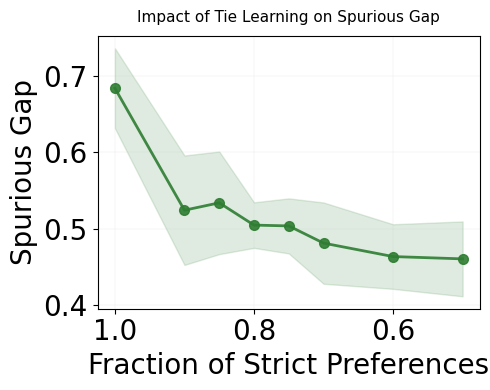

,alpha_strict,gapP_mean,gapP_std
0,1.00,0.684377,0.052473
1,0.90,0.524115,0.071891
2,0.85,0.533829,0.067419
3,0.80,0.504552,0.029919
4,0.75,0.503495,0.036158
5,0.70,0.480887,0.053389
6,0.60,0.463232,0.042436
7,0.50,0.460179,0.049190


In [11]:

# =========================
# Experiment: Gap vs \alpha
# =========================
run_gapP_vs_alpha(
        out_dir=out_dir,
        device=device,
        seeds=seeds,
        alphas=alphas,
        n_train_pairs=50000,
        beta_teacher=1.0,
        n_eval_pairs=30000,
        cfg=cfg,
    )

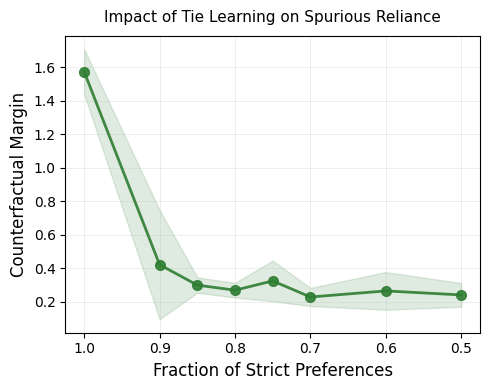

,alpha_strict,cf_margin_mean,cf_margin_std
0,1.00,1.572997,0.134475
1,0.90,0.420673,0.325765
2,0.85,0.298883,0.045878
3,0.80,0.268342,0.043666
4,0.75,0.323948,0.121602
5,0.70,0.227716,0.054046
6,0.60,0.264091,0.112733
7,0.50,0.240104,0.070713


In [12]:
# ===========================================
# Experiment: Conter-factual margin vs \alpha
# ===========================================
run_cf_margin_vs_alpha(
        out_dir=out_dir,
        device=device,
        seeds=seeds,
        alphas=alphas,
        n_train_pairs=50000,
        beta_teacher=1.0,     # 2.0 forces better response (analyze)
        n_eval_cf=20000,
        cfg=cfg,
    )

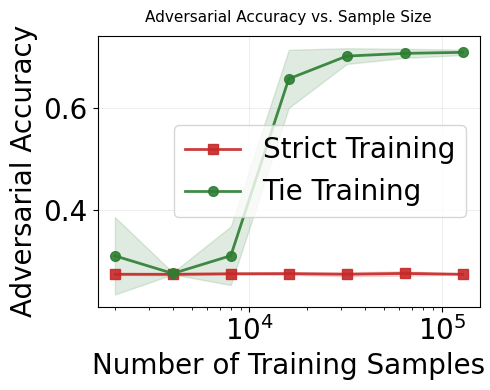

,N_train_pairs,adv_acc_strict_mean,adv_acc_strict_std,adv_acc_tie_a075_mean,adv_acc_tie_a075_std
0,2000,0.274000,0.001261,0.310007,0.075637
1,4000,0.273920,0.002093,0.275527,0.001861
2,8000,0.274947,0.001489,0.310260,0.057296
3,16000,0.275220,0.002489,0.656167,0.056815
4,32000,0.274007,0.003796,0.700720,0.015419
5,64000,0.275593,0.004447,0.706033,0.008851
6,128000,0.273927,0.000510,0.708033,0.005304


In [13]:
# ==============================================================
# Experiment: Adversarial accuracy vs number of training samples
# ==============================================================
run_adv_acc_vs_N(
        out_dir=out_dir,
        device=device,
        seeds=seeds,
        Ns=Ns,
        alpha_tie=0.75,
        n_eval_pairs=30000,
        beta_teacher=1.0,
        cfg=cfg,
    )